# NPL 예측 — 하이퍼파라미터 튜닝

v3에서 최고 성능을 보인 **LightGBM**과 **Random Forest**를 TimeSeriesSplit 교차검증으로 튜닝합니다.

- 예측 방식: NPL 변화량 예측 후 복원 (v3와 동일)
- 튜닝 방법: RandomizedSearchCV + TimeSeriesSplit(n_splits=5)
- Train: 2011Q4~2022Q4 / Test: 2023Q1~2025Q3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import randint, uniform

from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from lightgbm                import LGBMRegressor

plt.rcParams['font.family']        = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('준비 완료')

준비 완료


In [2]:
# -------------------------------------------------------
# 1. 데이터 준비 (v3와 동일한 피처 엔지니어링)
# -------------------------------------------------------
df = pd.read_csv('../data/processed/dataset.csv')

macro_cols = ['base_rate', 'deposit_rate', 'loan_rate',
              'unemployment_rate', 'household_loan_balance']

for col in macro_cols:
    df[col + '_lag1']  = df[col].shift(1)
    df[col + '_diff1'] = df[col].diff(1)

df['NPL_lag1']    = df['NPL비율'].shift(1)
df['NPL_diff1']   = df['NPL비율'].diff(1)
df['NPL_diff2']   = df['NPL비율'].diff(2)

# 타겟: 다음 분기 NPL 변화량
df['target_diff'] = df['NPL비율'].shift(-1) - df['NPL비율']
df['current_npl'] = df['NPL비율']

df_model = df.dropna().reset_index(drop=True)

feature_cols = (
    macro_cols
    + [c + '_lag1'  for c in macro_cols]
    + [c + '_diff1' for c in macro_cols]
    + ['NPL_lag1', 'NPL_diff1', 'NPL_diff2']
)

train_mask = df_model['quarter'] <= '2022Q4'
test_mask  = df_model['quarter'] >= '2023Q1'

X_train       = df_model.loc[train_mask, feature_cols].values
y_train       = df_model.loc[train_mask, 'target_diff'].values
npl_train     = df_model.loc[train_mask, 'current_npl'].values

X_test        = df_model.loc[test_mask, feature_cols].values
y_test_diff   = df_model.loc[test_mask, 'target_diff'].values
npl_test      = df_model.loc[test_mask, 'current_npl'].values
test_quarters = df_model.loc[test_mask, 'quarter'].tolist()

y_test_npl = npl_test + y_test_diff  # 실제 다음 분기 NPL

print(f'Train: {len(X_train)}개, Test: {len(X_test)}개, 피처: {len(feature_cols)}개')

Train: 43개, Test: 11개, 피처: 18개


In [3]:
# -------------------------------------------------------
# 2. v3 기본 성능 (튜닝 전 기준선)
# -------------------------------------------------------
lgbm_base = LGBMRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
rf_base = RandomForestRegressor(
    n_estimators=200, max_depth=4, random_state=42
)

lgbm_base.fit(X_train, y_train)
rf_base.fit(X_train, y_train)

def evaluate_npl(model, X_te, npl_te, y_npl_true):
    """변화량 예측 -> NPL 복원 -> 평가 지표 반환"""
    pred_diff = model.predict(X_te)
    pred_npl  = npl_te + pred_diff
    rmse = np.sqrt(mean_squared_error(y_npl_true, pred_npl))
    mae  = mean_absolute_error(y_npl_true, pred_npl)
    r2   = r2_score(y_npl_true, pred_npl)
    mape = np.mean(np.abs((y_npl_true - pred_npl) / y_npl_true)) * 100
    return pred_npl, dict(RMSE=round(rmse,4), MAE=round(mae,4),
                          R2=round(r2,4), MAPE=round(mape,2))

_, lgbm_base_scores = evaluate_npl(lgbm_base, X_test, npl_test, y_test_npl)
_, rf_base_scores   = evaluate_npl(rf_base,   X_test, npl_test, y_test_npl)

print('=== 튜닝 전 기준 성능 ===')
print(f'LightGBM (기본):  RMSE={lgbm_base_scores["RMSE"]}  R2={lgbm_base_scores["R2"]}  MAPE={lgbm_base_scores["MAPE"]}%')
print(f'RandomForest (기본): RMSE={rf_base_scores["RMSE"]}  R2={rf_base_scores["R2"]}  MAPE={rf_base_scores["MAPE"]}%')

=== 튜닝 전 기준 성능 ===
LightGBM (기본):  RMSE=0.0171  R2=0.9112  MAPE=2.37%
RandomForest (기본): RMSE=0.0344  R2=0.6422  MAPE=5.61%


In [4]:
# -------------------------------------------------------
# 3. TimeSeriesSplit 교차검증 설정
# -------------------------------------------------------
# 시계열이므로 일반 k-fold 대신 TimeSeriesSplit 사용
# - 과거 데이터로 학습, 미래 데이터로 검증 (미래 누수 방지)
tscv = TimeSeriesSplit(n_splits=5, gap=0)

print('TimeSeriesSplit 교차검증 구조 확인:')
print(f'  총 train 샘플: {len(X_train)}개')
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    print(f'  Fold {fold+1}: train={len(tr_idx)}개, val={len(val_idx)}개')

TimeSeriesSplit 교차검증 구조 확인:
  총 train 샘플: 43개
  Fold 1: train=8개, val=7개
  Fold 2: train=15개, val=7개
  Fold 3: train=22개, val=7개
  Fold 4: train=29개, val=7개
  Fold 5: train=36개, val=7개


In [5]:
# -------------------------------------------------------
# 4. LightGBM 하이퍼파라미터 튜닝
# -------------------------------------------------------
lgbm_param_dist = {
    'n_estimators':      randint(50, 500),
    'max_depth':         randint(2, 6),
    'num_leaves':        randint(7, 64),
    'learning_rate':     uniform(0.01, 0.19),    # 0.01 ~ 0.20
    'subsample':         uniform(0.5, 0.5),       # 0.5 ~ 1.0
    'colsample_bytree':  uniform(0.5, 0.5),       # 0.5 ~ 1.0
    'min_child_samples': randint(3, 20),
    'reg_alpha':         uniform(0, 1.0),
    'reg_lambda':        uniform(0, 1.0),
}

lgbm_search = RandomizedSearchCV(
    estimator  = LGBMRegressor(random_state=42, verbose=-1),
    param_distributions = lgbm_param_dist,
    n_iter     = 50,
    cv         = tscv,
    scoring    = 'neg_root_mean_squared_error',  # RMSE 최소화
    n_jobs     = -1,
    random_state = 42,
    refit      = True,
)

print('LightGBM 튜닝 시작 (n_iter=50, 5-fold)...')
lgbm_search.fit(X_train, y_train)

print('완료!')
print('\n최적 파라미터:')
for k, v in lgbm_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nCV 최적 RMSE: {-lgbm_search.best_score_:.4f}')

LightGBM 튜닝 시작 (n_iter=50, 5-fold)...


완료!

최적 파라미터:
  colsample_bytree: 0.6354161256310371
  learning_rate: 0.09340456993407086
  max_depth: 4
  min_child_samples: 7
  n_estimators: 166
  num_leaves: 29
  reg_alpha: 0.42831447494010777
  reg_lambda: 0.6884999007653664
  subsample: 0.5290967977542218

CV 최적 RMSE: 0.0865


In [6]:
# -------------------------------------------------------
# 5. Random Forest 하이퍼파라미터 튜닝
# -------------------------------------------------------
rf_param_dist = {
    'n_estimators':     randint(50, 400),
    'max_depth':        [2, 3, 4, 5, 6, None],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf':  randint(1, 8),
    'max_features':     ['sqrt', 'log2', 0.5, 0.7],
    'bootstrap':        [True, False],
}

rf_search = RandomizedSearchCV(
    estimator  = RandomForestRegressor(random_state=42),
    param_distributions = rf_param_dist,
    n_iter     = 50,
    cv         = tscv,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1,
    random_state = 42,
    refit      = True,
)

print('Random Forest 튜닝 시작 (n_iter=50, 5-fold)...')
rf_search.fit(X_train, y_train)

print('완료!')
print('\n최적 파라미터:')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nCV 최적 RMSE: {-rf_search.best_score_:.4f}')

Random Forest 튜닝 시작 (n_iter=50, 5-fold)...


완료!

최적 파라미터:
  bootstrap: True
  max_depth: 3
  max_features: log2
  min_samples_leaf: 4
  min_samples_split: 14
  n_estimators: 228

CV 최적 RMSE: 0.0846


In [7]:
# -------------------------------------------------------
# 6. 튜닝 전후 성능 비교
# -------------------------------------------------------
lgbm_tuned_pred, lgbm_tuned_scores = evaluate_npl(
    lgbm_search.best_estimator_, X_test, npl_test, y_test_npl
)
rf_tuned_pred, rf_tuned_scores = evaluate_npl(
    rf_search.best_estimator_, X_test, npl_test, y_test_npl
)

compare_df = pd.DataFrame([
    {'모델': 'LightGBM (기본)',  **lgbm_base_scores},
    {'모델': 'LightGBM (튜닝)', **lgbm_tuned_scores},
    {'모델': 'RandomForest (기본)',  **rf_base_scores},
    {'모델': 'RandomForest (튜닝)', **rf_tuned_scores},
])

print('=== 튜닝 전후 성능 비교 ===')
print(compare_df.to_string(index=False))

=== 튜닝 전후 성능 비교 ===
               모델   RMSE    MAE     R2  MAPE
    LightGBM (기본) 0.0171 0.0123 0.9112  2.37
    LightGBM (튜닝) 0.0455 0.0406 0.3739  7.90
RandomForest (기본) 0.0344 0.0283 0.6422  5.61
RandomForest (튜닝) 0.0217 0.0147 0.8581  2.78


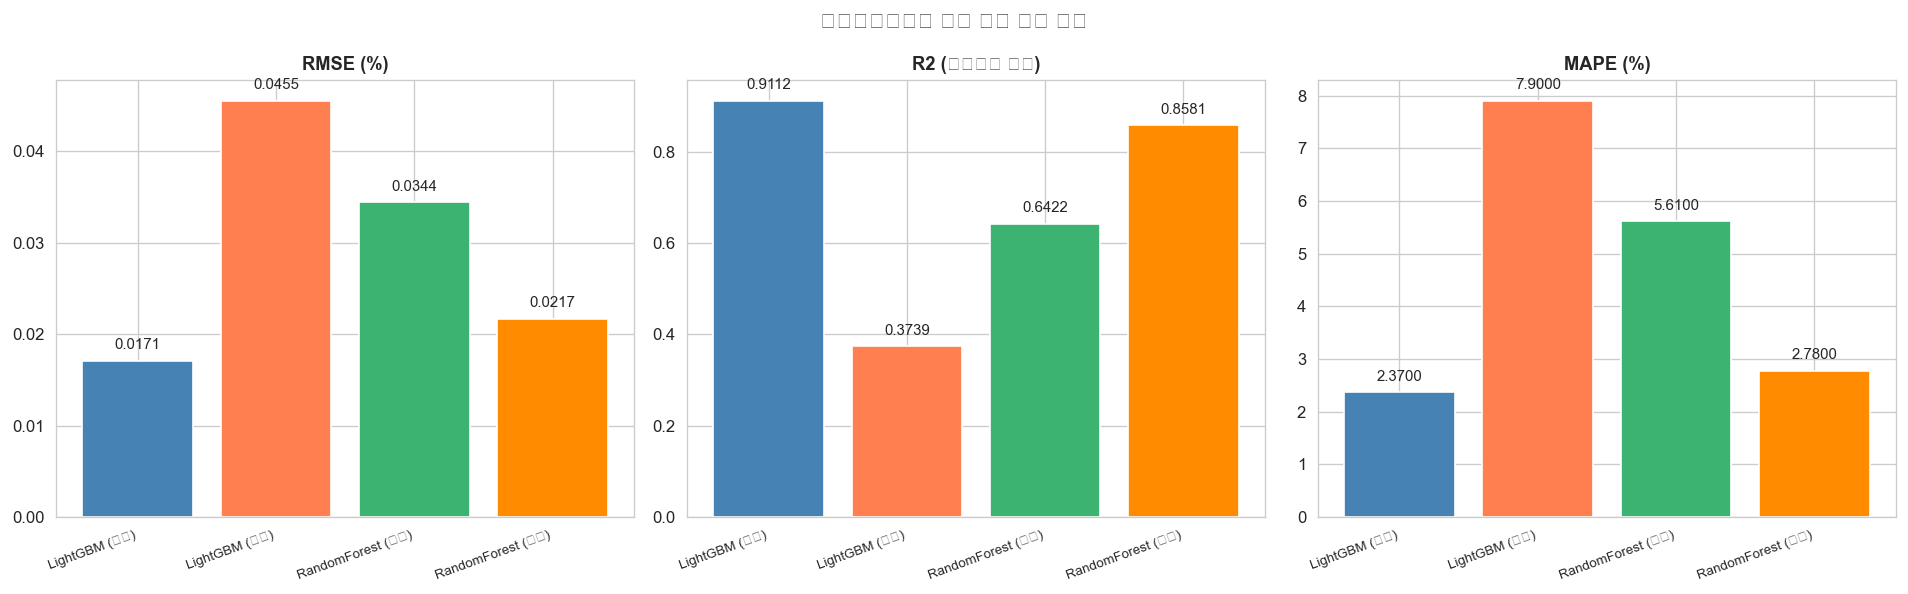

In [8]:
# -------------------------------------------------------
# 7. 튜닝 전후 성능 시각화
# -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['RMSE', 'R2', 'MAPE']
labels  = ['RMSE (%)', 'R2 (높을수록 좋음)', 'MAPE (%)']

for ax, metric, label in zip(axes, metrics, labels):
    vals   = compare_df[metric].tolist()
    colors = ['steelblue', 'coral', 'mediumseagreen', 'darkorange']
    bars   = ax.bar(compare_df['모델'], vals, color=colors, edgecolor='white')

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(max(vals)) * 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticklabels(compare_df['모델'], rotation=20, ha='right', fontsize=8)

fig.suptitle('하이퍼파라미터 튜닝 전후 성능 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_tuning_comparison.png', bbox_inches='tight')
plt.show()

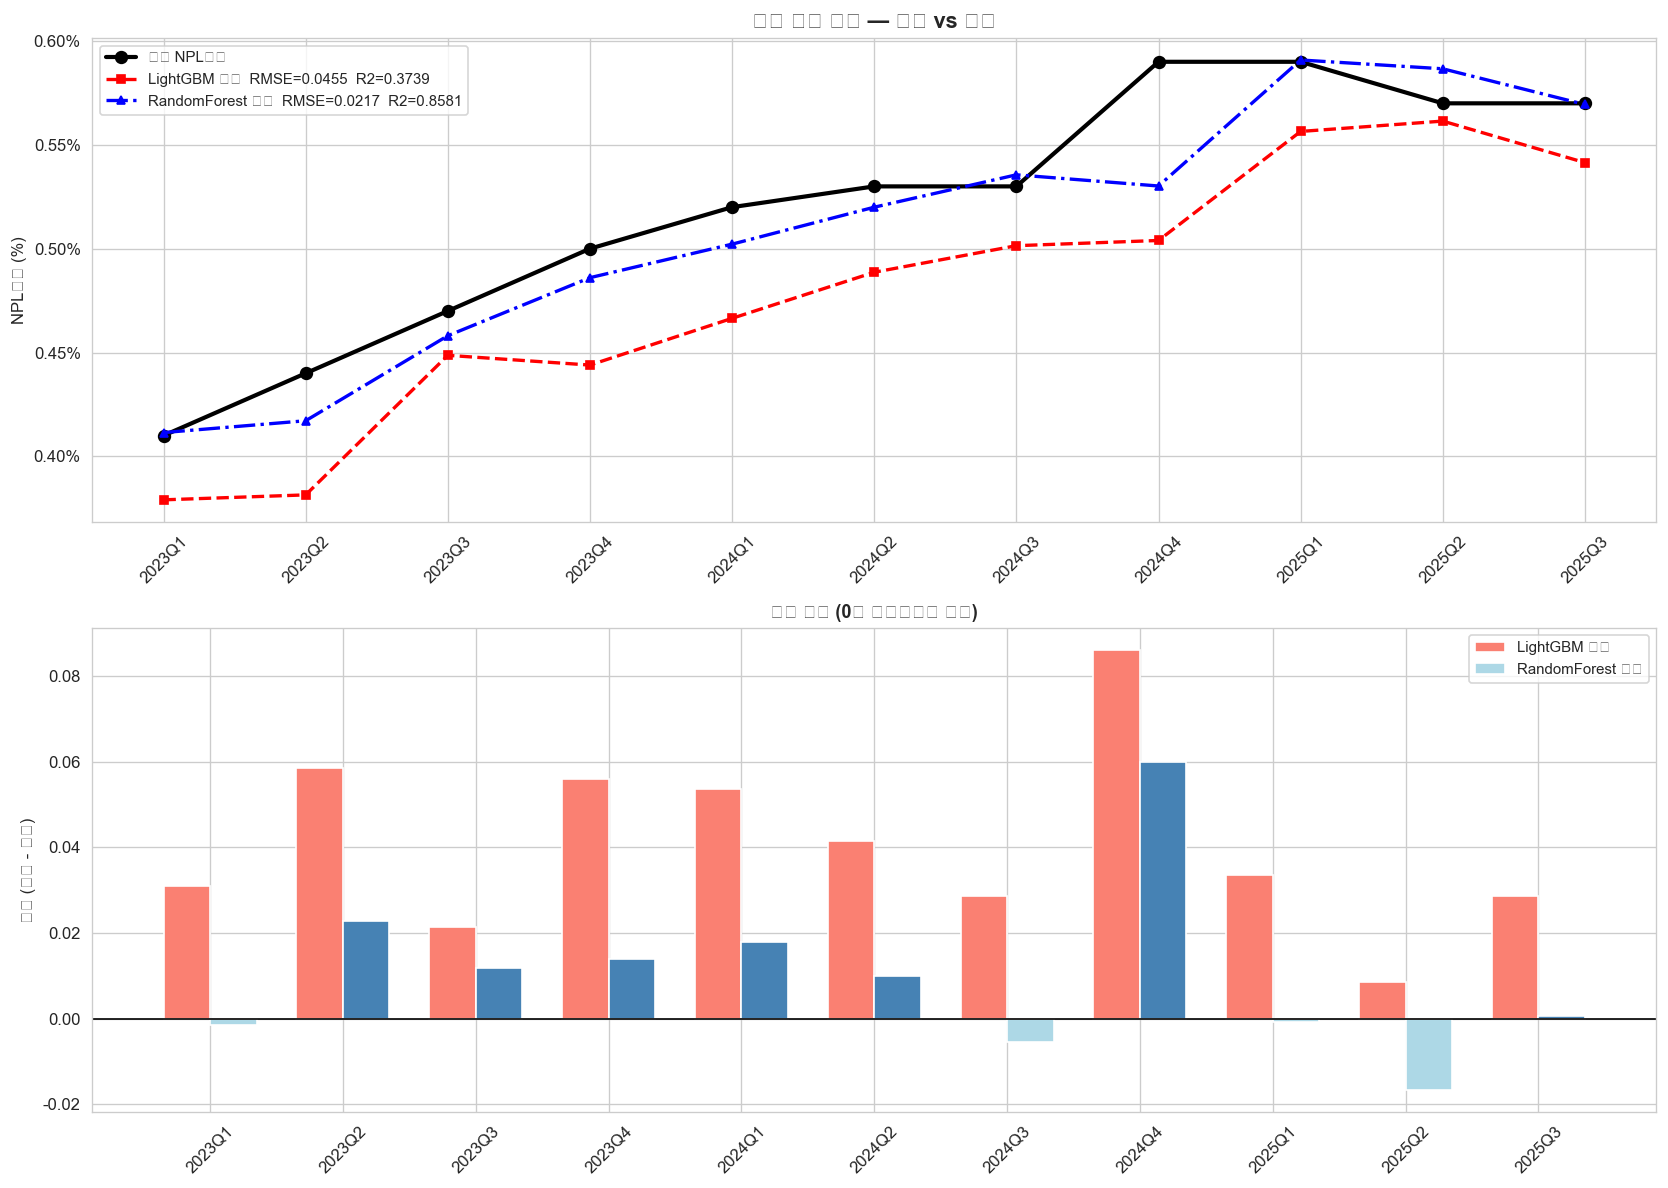

In [9]:
# -------------------------------------------------------
# 8. 최종 최고 모델 예측 vs 실제 시계열
# -------------------------------------------------------
# RMSE 기준 최고 모델 선택
best_entry = compare_df.sort_values('RMSE').iloc[0]
best_label = best_entry['모델']

if 'LightGBM' in best_label and '튜닝' in best_label:
    best_pred = lgbm_tuned_pred
elif 'LightGBM' in best_label:
    best_pred, _ = evaluate_npl(lgbm_base, X_test, npl_test, y_test_npl)
elif 'RandomForest' in best_label and '튜닝' in best_label:
    best_pred = rf_tuned_pred
else:
    best_pred, _ = evaluate_npl(rf_base, X_test, npl_test, y_test_npl)

residuals = y_test_npl - best_pred

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 시계열 비교
ax = axes[0]
x_range = range(len(test_quarters))
ax.plot(x_range, y_test_npl,  'ko-', linewidth=2.5, markersize=7, label='실제 NPL비율')
ax.plot(x_range, lgbm_tuned_pred, 'r--s', linewidth=2, markersize=5, label=f'LightGBM 튜닝  RMSE={lgbm_tuned_scores["RMSE"]}  R2={lgbm_tuned_scores["R2"]}')
ax.plot(x_range, rf_tuned_pred,   'b-.^', linewidth=2, markersize=5, label=f'RandomForest 튜닝  RMSE={rf_tuned_scores["RMSE"]}  R2={rf_tuned_scores["R2"]}')
ax.set_xticks(x_range)
ax.set_xticklabels(test_quarters, rotation=45)
ax.set_ylabel('NPL비율 (%)')
ax.set_title('최종 튜닝 모델 — 예측 vs 실제', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

# 잔차
ax = axes[1]
width = 0.35
lgbm_res = y_test_npl - lgbm_tuned_pred
rf_res   = y_test_npl - rf_tuned_pred
ax.bar(np.arange(len(test_quarters)) - width/2, lgbm_res, width,
       color=['coral' if r<0 else 'salmon' for r in lgbm_res],
       label='LightGBM 잔차', edgecolor='white')
ax.bar(np.arange(len(test_quarters)) + width/2, rf_res, width,
       color=['lightblue' if r<0 else 'steelblue' for r in rf_res],
       label='RandomForest 잔차', edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(test_quarters)))
ax.set_xticklabels(test_quarters, rotation=45)
ax.set_ylabel('잔차 (실제 - 예측)')
ax.set_title('잔차 비교 (0에 가까울수록 정확)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/fig_final_prediction.png', bbox_inches='tight')
plt.show()

In [10]:
# -------------------------------------------------------
# 9. 최종 모델 분기별 상세 결과
# -------------------------------------------------------
def next_quarter_label(q):
    year, qnum = int(q[:4]), int(q[-1])
    return f'{year}Q{qnum+1}' if qnum < 4 else f'{year+1}Q1'

final_df = pd.DataFrame({
    '입력분기':          test_quarters,
    '예측대상분기':      [next_quarter_label(q) for q in test_quarters],
    '실제NPL(%)':       y_test_npl.round(3),
    'LightGBM튜닝(%)':  lgbm_tuned_pred.round(3),
    'LGBM오차':         lgbm_res.round(3),
    'RF튜닝(%)':        rf_tuned_pred.round(3),
    'RF오차':           rf_res.round(3),
})

print('=== 최종 분기별 예측 결과 ===')
print(final_df.to_string(index=False))

print(f'\n--- LightGBM 튜닝 ---')
print(f'  RMSE: {lgbm_tuned_scores["RMSE"]}%  |  MAE: {lgbm_tuned_scores["MAE"]}%  |  R2: {lgbm_tuned_scores["R2"]}  |  MAPE: {lgbm_tuned_scores["MAPE"]}%')

print(f'\n--- RandomForest 튜닝 ---')
print(f'  RMSE: {rf_tuned_scores["RMSE"]}%  |  MAE: {rf_tuned_scores["MAE"]}%  |  R2: {rf_tuned_scores["R2"]}  |  MAPE: {rf_tuned_scores["MAPE"]}%')

=== 최종 분기별 예측 결과 ===
  입력분기 예측대상분기  실제NPL(%)  LightGBM튜닝(%)  LGBM오차  RF튜닝(%)   RF오차
2023Q1 2023Q2      0.41          0.379   0.031    0.411 -0.001
2023Q2 2023Q3      0.44          0.381   0.059    0.417  0.023
2023Q3 2023Q4      0.47          0.449   0.021    0.458  0.012
2023Q4 2024Q1      0.50          0.444   0.056    0.486  0.014
2024Q1 2024Q2      0.52          0.466   0.054    0.502  0.018
2024Q2 2024Q3      0.53          0.489   0.041    0.520  0.010
2024Q3 2024Q4      0.53          0.501   0.029    0.536 -0.006
2024Q4 2025Q1      0.59          0.504   0.086    0.530  0.060
2025Q1 2025Q2      0.59          0.556   0.034    0.591 -0.001
2025Q2 2025Q3      0.57          0.561   0.009    0.587 -0.017
2025Q3 2025Q4      0.57          0.541   0.029    0.569  0.001

--- LightGBM 튜닝 ---
  RMSE: 0.0455%  |  MAE: 0.0406%  |  R2: 0.3739  |  MAPE: 7.9%

--- RandomForest 튜닝 ---
  RMSE: 0.0217%  |  MAE: 0.0147%  |  R2: 0.8581  |  MAPE: 2.78%


In [11]:
# -------------------------------------------------------
# 10. 최적 파라미터 최종 정리
# -------------------------------------------------------
print('=== LightGBM 최적 파라미터 ===')
for k, v in sorted(lgbm_search.best_params_.items()):
    base_val = {'n_estimators':200, 'max_depth':3, 'learning_rate':0.05,
                'subsample':0.8, 'colsample_bytree':0.8}.get(k, '-')
    print(f'  {k:25s}: {str(v):>10}   (기본값: {base_val})')

print()
print('=== RandomForest 최적 파라미터 ===')
for k, v in sorted(rf_search.best_params_.items()):
    base_val = {'n_estimators':200, 'max_depth':4}.get(k, '-')
    print(f'  {k:25s}: {str(v):>10}   (기본값: {base_val})')

=== LightGBM 최적 파라미터 ===
  colsample_bytree         : 0.6354161256310371   (기본값: 0.8)
  learning_rate            : 0.09340456993407086   (기본값: 0.05)
  max_depth                :          4   (기본값: 3)
  min_child_samples        :          7   (기본값: -)
  n_estimators             :        166   (기본값: 200)
  num_leaves               :         29   (기본값: -)
  reg_alpha                : 0.42831447494010777   (기본값: -)
  reg_lambda               : 0.6884999007653664   (기본값: -)
  subsample                : 0.5290967977542218   (기본값: 0.8)

=== RandomForest 최적 파라미터 ===
  bootstrap                :       True   (기본값: -)
  max_depth                :          3   (기본값: 4)
  max_features             :       log2   (기본값: -)
  min_samples_leaf         :          4   (기본값: -)
  min_samples_split        :         14   (기본값: -)
  n_estimators             :        228   (기본값: 200)
